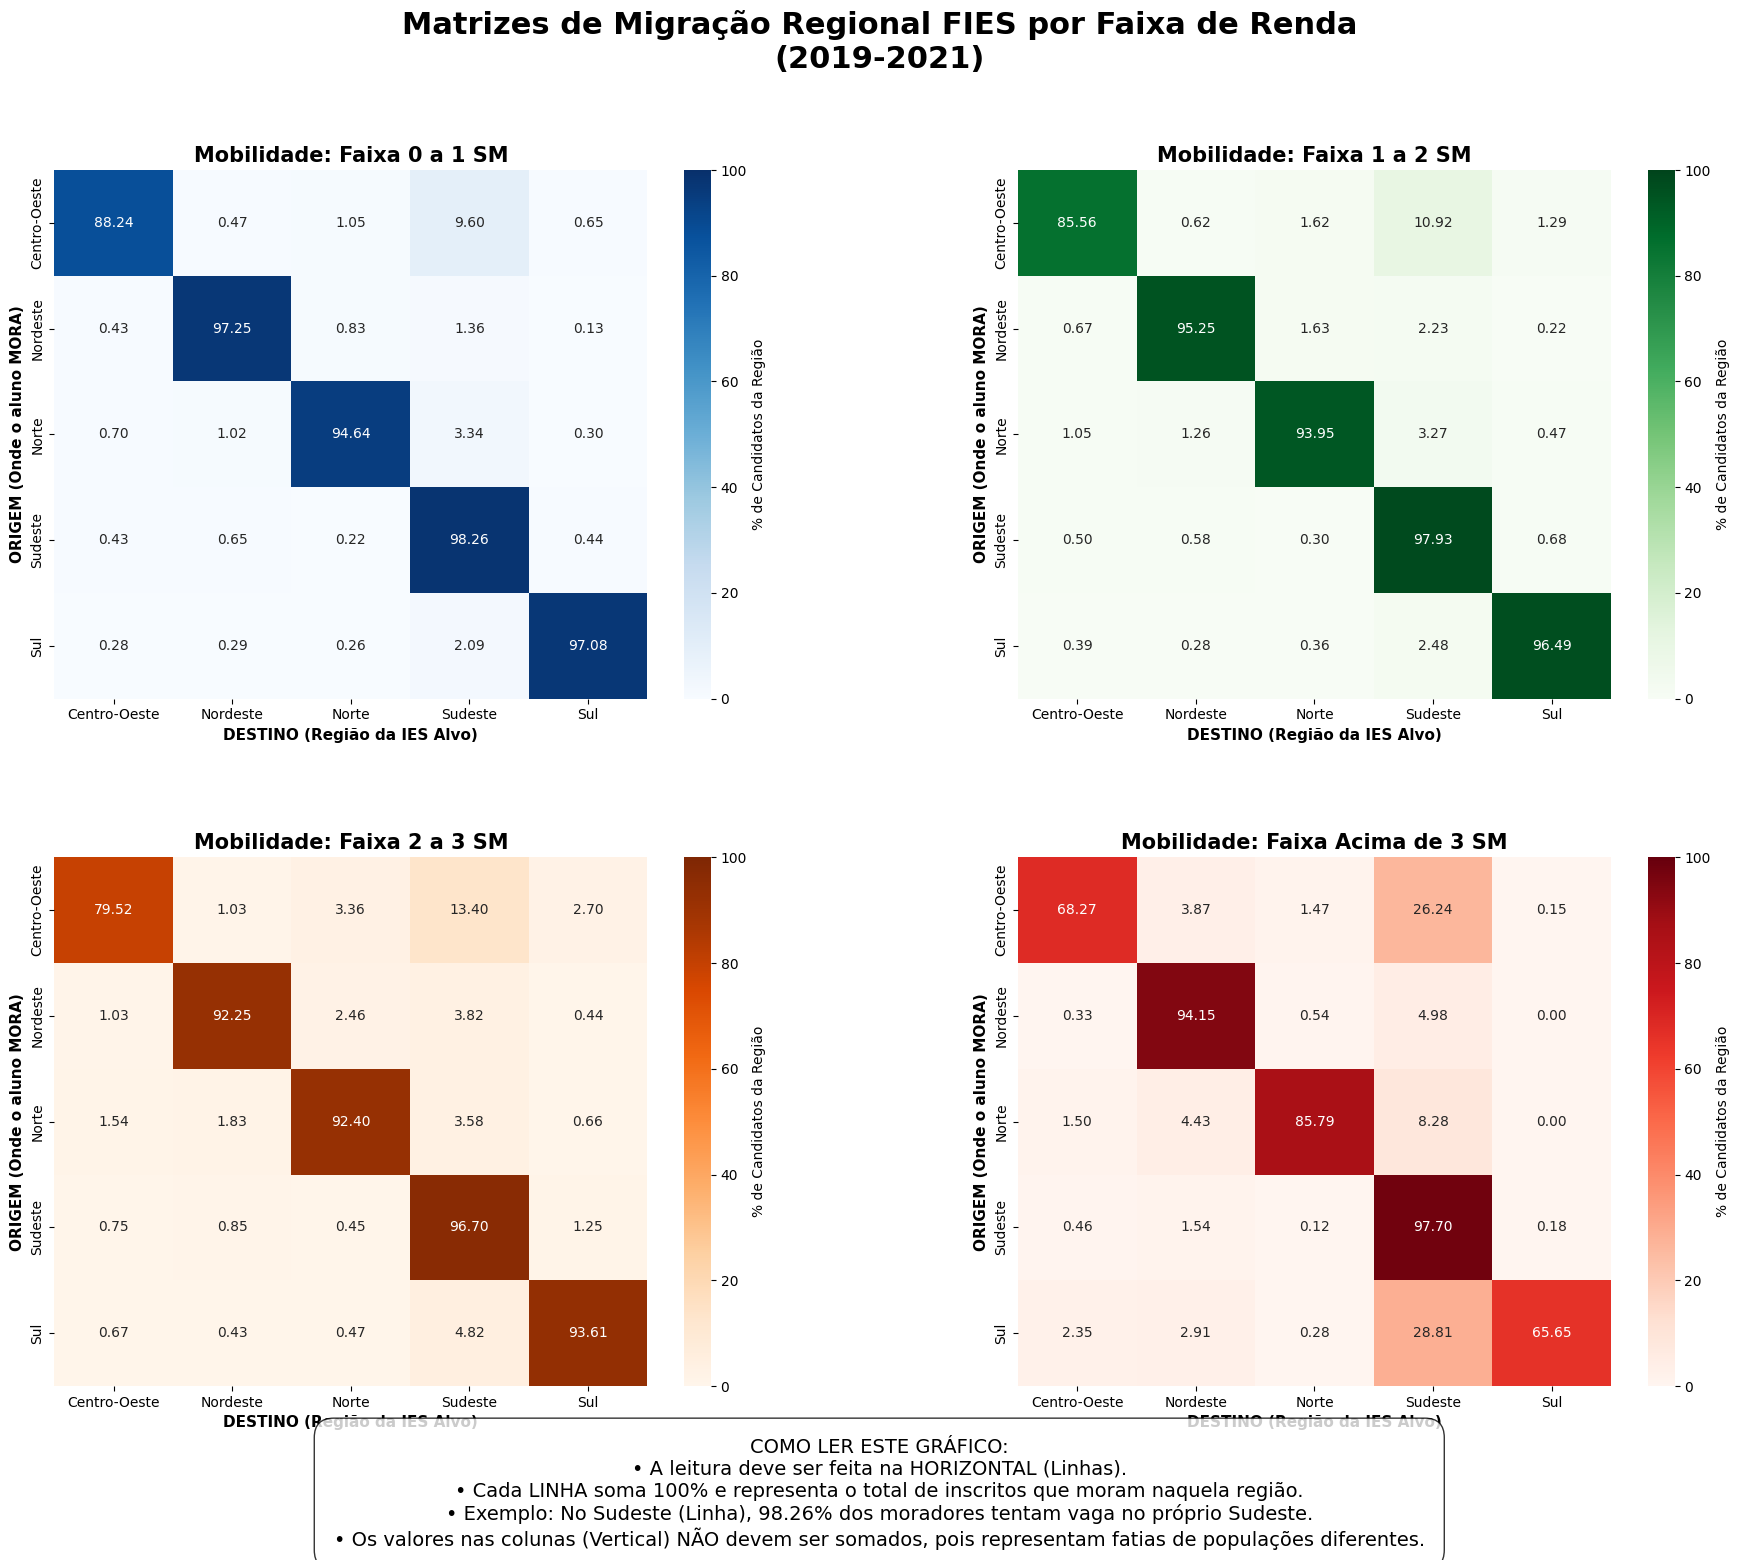


📊 DATASET DE APOIO: VOLUME DE PESSOAS POR FAIXA


,faixa_renda,Qtd_Inscritos,Participação
0,0 a 1 SM,1335331,60.77%
1,1 a 2 SM,690733,31.44%
2,2 a 3 SM,158716,7.22%
3,Acima de 3 SM,12436,0.57%


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from constantes import pasta_data_04_load_database

# ==============================================================================
# 0. CONFIGURAÇÃO E CARREGAMENTO
# ==============================================================================
pasta_destino_graficos = Path('../reports/figures/analise_004').resolve()
pasta_destino_graficos.mkdir(parents=True, exist_ok=True)

caminho_inscritos = pasta_data_04_load_database / 'inscritos_final_limpo.parquet'
df = pd.read_parquet(str(caminho_inscritos))

df_analise = df.dropna(subset=['regiao_morar', 'regiao_ies_alvo', 'renda_per_capita']).copy()

# ==============================================================================
# 1. DEFINIÇÃO DE FAIXAS (Salário Mínimo Real por Ano)
# ==============================================================================
dict_sm = {2019: 998.00, 2020: 1045.00, 2021: 1100.00}
df_analise['sm_ano'] = df_analise['ano'].map(dict_sm)
df_analise['qtd_sm_per_capita'] = df_analise['renda_per_capita'] / df_analise['sm_ano']

limites = [-np.inf, 1, 2, 3, np.inf]
nomes_faixas = ['0 a 1 SM', '1 a 2 SM', '2 a 3 SM', 'Acima de 3 SM']
df_analise['faixa_renda'] = pd.cut(df_analise['qtd_sm_per_capita'], bins=limites, labels=nomes_faixas)

# ==============================================================================
# 2. GERAÇÃO DOS GRÁFICOS COM NOTA EXPLICATIVA
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.flatten()
paletas = ['Blues', 'Greens', 'Oranges', 'Reds']

for i, faixa in enumerate(nomes_faixas):
    df_f = df_analise[df_analise['faixa_renda'] == faixa]
    
    # normalize='index' -> Faz a linha somar 100%
    matriz = pd.crosstab(df_f['regiao_morar'], df_f['regiao_ies_alvo'], normalize='index') * 100
    
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap=paletas[i], ax=axes[i], vmin=0, vmax=100,
                cbar_kws={'label': '% de Candidatos da Região'})
    
    axes[i].set_title(f'Mobilidade: Faixa {faixa}', fontsize=15, fontweight='bold')
    axes[i].set_ylabel('ORIGEM (Onde o aluno MORA)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('DESTINO (Região da IES Alvo)', fontsize=11, fontweight='bold')

# TÍTULO PRINCIPAL
fig.suptitle('Matrizes de Migração Regional FIES por Faixa de Renda\n(2019-2021)', 
             fontsize=22, fontweight='bold', y=0.98)

# 🚨 AQUI ESTÁ A EXPLICAÇÃO QUE VOCÊ PEDIU:
# Adicionamos um texto no fundo do gráfico para guiar o leitor
nota_explicativa = (
    "COMO LER ESTE GRÁFICO:\n"
    "• A leitura deve ser feita na HORIZONTAL (Linhas).\n"
    "• Cada LINHA soma 100% e representa o total de inscritos que moram naquela região.\n"
    "• Exemplo: No Sudeste (Linha), 98.26% dos moradores tentam vaga no próprio Sudeste.\n"
    "• Os valores nas colunas (Vertical) NÃO devem ser somados, pois representam fatias de populações diferentes."
)

fig.text(0.5, 0.02, nota_explicativa, ha='center', fontsize=14, 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=1'))

plt.subplots_adjust(hspace=0.3, wspace=0.3, bottom=0.12)

# Salvar e mostrar
plt.savefig(pasta_destino_graficos / 'heatmaps_mobilidade_com_legenda.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 3. VOLUMETRIA (Dataset via display)
# ==============================================================================
df_volumetria = df_analise.groupby('faixa_renda', observed=False).size().reset_index(name='Qtd_Inscritos')
df_volumetria['Participação'] = (df_volumetria['Qtd_Inscritos'] / len(df_analise) * 100).round(2).astype(str) + '%'

print("\n📊 DATASET DE APOIO: VOLUME DE PESSOAS POR FAIXA")
display(df_volumetria)